## Linear Regression - House price Predication

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv(r'california_housing.csv')
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,5.9308,18.0,9.5791,2.1144,17489.0,5.2289,40.1498,-117.7945,3.442
1,14.2854,18.9,1.5793,2.1031,5610.0,6.8220,37.2375,-114.7944,5.000
2,11.1139,3.6,1.2585,1.0400,30287.0,7.2450,40.0355,-116.1782,5.000
3,9.1805,7.1,2.5753,2.5418,4520.0,2.3099,34.9989,-122.6675,3.945
4,2.7623,10.9,9.3618,2.8215,25232.0,9.3494,40.4655,-117.0856,2.201
...,...,...,...,...,...,...,...,...,...
20635,6.1727,44.2,6.5725,2.2959,16115.0,7.7153,36.3495,-123.9333,3.529
20636,14.5838,44.5,3.8495,1.5249,31416.0,2.1156,37.5123,-122.8112,5.000
20637,5.5915,30.5,9.9370,1.6824,9924.0,7.4387,38.9419,-121.2545,3.093
20638,13.0835,45.2,6.8951,1.0996,20338.0,5.1560,32.8827,-116.1781,5.000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [17]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

In [23]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [25]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,5.9308,18.0,9.5791,2.1144,17489.0,5.2289,40.1498,-117.7945,3.442
1,14.2854,18.9,1.5793,2.1031,5610.0,6.8220,37.2375,-114.7944,5.000
2,11.1139,3.6,1.2585,1.0400,30287.0,7.2450,40.0355,-116.1782,5.000
3,9.1805,7.1,2.5753,2.5418,4520.0,2.3099,34.9989,-122.6675,3.945
4,2.7623,10.9,9.3618,2.8215,25232.0,9.3494,40.4655,-117.0856,2.201


In [27]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
20635,6.1727,44.2,6.5725,2.2959,16115.0,7.7153,36.3495,-123.9333,3.529
20636,14.5838,44.5,3.8495,1.5249,31416.0,2.1156,37.5123,-122.8112,5.000
20637,5.5915,30.5,9.9370,1.6824,9924.0,7.4387,38.9419,-121.2545,3.093
20638,13.0835,45.2,6.8951,1.0996,20338.0,5.1560,32.8827,-116.1781,5.000
20639,1.8516,40.7,7.3287,2.9065,29506.0,3.4192,36.7884,-117.7438,1.398


In [21]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,7.743434,26.469181,5.495059,2.003317,17903.616957,5.499838,37.210993,-119.305159,3.535983
std,4.182018,14.698716,2.592404,0.575186,10262.929661,2.598158,2.714311,2.903677,1.408464
min,0.500200,1.000000,1.000100,1.000300,7.000000,1.002100,32.540000,-124.349800,0.150000
25%,4.131950,13.800000,3.263175,1.503600,9066.750000,3.237175,34.860050,-121.828850,2.377750
50%,7.737300,26.500000,5.488400,2.010550,17927.500000,5.510800,37.179050,-119.315750,3.811000
75%,11.368325,39.100000,7.744400,2.504925,26753.500000,7.737975,39.538275,-116.786775,5.000000
max,14.998900,52.000000,9.999700,2.999800,35679.000000,9.999300,41.949400,-114.310200,5.000000


## Visualization 1- Price Distribution

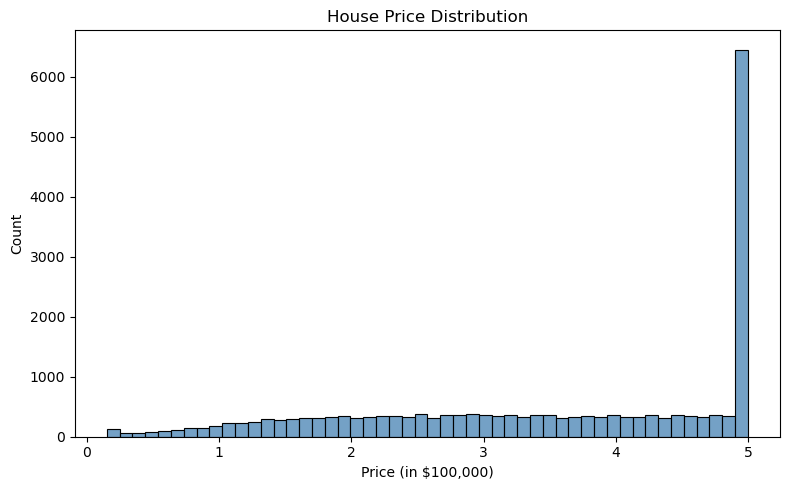

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, color='steelblue')
plt.title('House Price Distribution')
plt.xlabel('Price (in $100,000)')
plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()

## Visualization 2-Correlation HeatMap

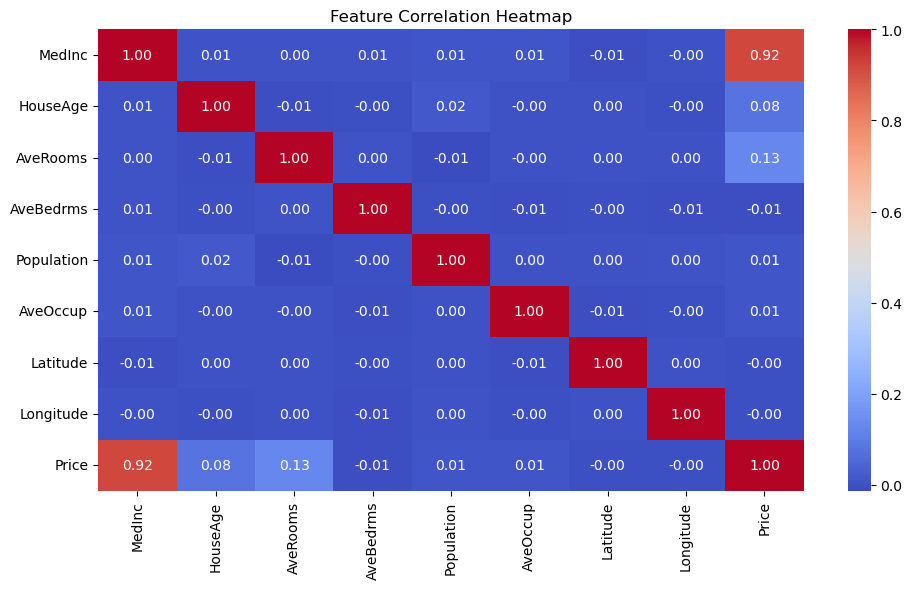

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [ ]:
## Model Building

In [53]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [57]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [59]:
X = df[['MedInc', 'AveRooms', 'AveBedrms', 'Population']]
y = df['Price']
y_pred = model.predict(X_test)
y_pred

array([2.82993577, 1.4371359 , 2.87811436, ..., 2.98454386, 3.21189148,
       3.1921004 ])

## Results

In [64]:
print("\n✅ Model Results:")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")


✅ Model Results:
R² Score: 0.86
MSE: 0.28


## Visualization 3- Actual vs Predicated

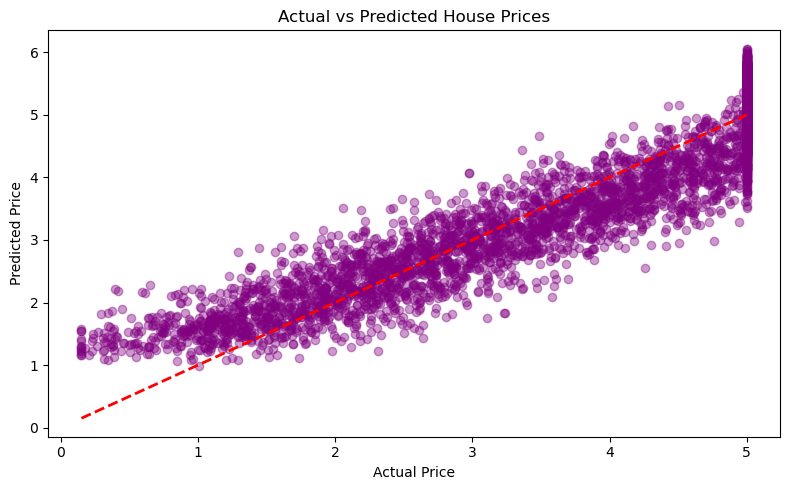

In [67]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()